## Importação das Dependências e Configurações

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scripts.outliers import outlier_iqr

## Análise Inicial dos Datasets

In [2]:
df_avl_suspeitas = pd.read_csv("../data/projeto_02_avaliacoes_suspeitas.csv")
df_vendas = pd.read_csv("../data/projeto_02_ecommerce_vendas.csv")
df_vendedores = pd.read_csv("../data/projeto_02_vendedores_perfil.csv")

Descrição dos Dados

In [3]:
print('Informações Iniciais dos DataFrames -- Vendedores')
print('--'*100)
print(df_vendedores.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendedores
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vendedor_id          120 non-null    object 
 1   nome_loja            120 non-null    object 
 2   data_cadastro        120 non-null    object 
 3   cidade               120 non-null    object 
 4   estado               120 non-null    object 
 5   categoria_principal  120 non-null    object 
 6   total_vendas         120 non-null    int64  
 7   nota_media_loja      120 non-null    float64
 8   reclamacoes          120 non-null    int64  
 9   verificado           120 non-null    bool   
dtypes: bool(1), float64(1), int64(2), objec

In [4]:
print('Informações Iniciais dos DataFrames -- Vendas')
print('--'*100)
print(df_vendas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Vendas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pedido_id       8000 non-null   object 
 1   data_pedido     8000 non-null   object 
 2   hora_pedido     8000 non-null   object 
 3   vendedor_id     8000 non-null   object 
 4   categoria       8000 non-null   object 
 5   produto_id      8000 non-null   object 
 6   preco_unitario  8000 non-null   float64
 7   quantidade      8000 non-null   int64  
 8   valor_total     8000 non-null   float64
 9   frete           7767 non-null   float64
 10  estado_cliente  8000 non-null   object 
 11  status_pedido   8000 non-null   object 
 12  nota_avalia

In [5]:
print('Informações Iniciais dos DataFrames -- Avaliações suspeitas')
print('--'*100)
print(df_avl_suspeitas.info(), end='\n\n\n')

Informações Iniciais dos DataFrames -- Avaliações suspeitas
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   avaliacao_id        3000 non-null   object
 1   vendedor_id         3000 non-null   object
 2   comprador_id        3000 non-null   object
 3   data_avaliacao      3000 non-null   object
 4   data_criacao_conta  3000 non-null   object
 5   nota                3000 non-null   int64 
 6   ip_origem           3000 non-null   object
 7   texto_avaliacao     2668 non-null   object
dtypes: int64(1), object(7)
memory usage: 187.6+ KB
None




# Preparação dos Dados (Data Cleaning)

In [6]:
print("Quantidade de Valores distintos por Coluna (Vendas)\n")

for col in df_vendas.columns:
    print(f'Coluna: {col} - Quantidade de Valores Únicos: {pd.unique(df_vendas[col]).size}')


Quantidade de Valores distintos por Coluna (Vendas)

Coluna: pedido_id - Quantidade de Valores Únicos: 8000
Coluna: data_pedido - Quantidade de Valores Únicos: 730
Coluna: hora_pedido - Quantidade de Valores Únicos: 1355
Coluna: vendedor_id - Quantidade de Valores Únicos: 120
Coluna: categoria - Quantidade de Valores Únicos: 8
Coluna: produto_id - Quantidade de Valores Únicos: 500
Coluna: preco_unitario - Quantidade de Valores Únicos: 7058
Coluna: quantidade - Quantidade de Valores Únicos: 3
Coluna: valor_total - Quantidade de Valores Únicos: 7212
Coluna: frete - Quantidade de Valores Únicos: 3439
Coluna: estado_cliente - Quantidade de Valores Únicos: 15
Coluna: status_pedido - Quantidade de Valores Únicos: 4
Coluna: nota_avaliacao - Quantidade de Valores Únicos: 6


In [7]:
print("Quantidade de Valores distintos por Coluna (Vendedores)\n")

for col in df_vendedores.columns:
    print(f'Coluna: {col} - Quantidade de Valores Únicos: {pd.unique(df_vendedores[col]).size}')


Quantidade de Valores distintos por Coluna (Vendedores)

Coluna: vendedor_id - Quantidade de Valores Únicos: 120
Coluna: nome_loja - Quantidade de Valores Únicos: 119
Coluna: data_cadastro - Quantidade de Valores Únicos: 112
Coluna: cidade - Quantidade de Valores Únicos: 10
Coluna: estado - Quantidade de Valores Únicos: 15
Coluna: categoria_principal - Quantidade de Valores Únicos: 8
Coluna: total_vendas - Quantidade de Valores Únicos: 112
Coluna: nota_media_loja - Quantidade de Valores Únicos: 23
Coluna: reclamacoes - Quantidade de Valores Únicos: 29
Coluna: verificado - Quantidade de Valores Únicos: 2


In [8]:
print("Quantidade de Valores distintos por Coluna (Avaliações Suspeitas)\n")
for col in df_avl_suspeitas.columns:
    print(f'Coluna: {col} - Quantidade de Valores Únicos: {pd.unique(df_avl_suspeitas[col]).size}')


Quantidade de Valores distintos por Coluna (Avaliações Suspeitas)

Coluna: avaliacao_id - Quantidade de Valores Únicos: 3000
Coluna: vendedor_id - Quantidade de Valores Únicos: 120
Coluna: comprador_id - Quantidade de Valores Únicos: 2244
Coluna: data_avaliacao - Quantidade de Valores Únicos: 713
Coluna: data_criacao_conta - Quantidade de Valores Únicos: 1119
Coluna: nota - Quantidade de Valores Únicos: 5
Coluna: ip_origem - Quantidade de Valores Únicos: 2923
Coluna: texto_avaliacao - Quantidade de Valores Únicos: 14


## Transformando Dados

In [9]:
df_vendas['data_pedido_dt'] = pd.to_datetime(df_vendas['data_pedido'], format='%Y-%m-%d')
df_vendas['_hora_pedido'] = pd.to_datetime(df_vendas['hora_pedido'], format='%H:%M')

df_vendas['quantidade'] = df_vendas['quantidade'].astype("str").replace("nan", "0").astype("int")
df_vendas['preco_unitario'] = df_vendas['preco_unitario'].astype("float")
df_vendas['frete'] = df_vendas['frete'].fillna("-1").astype("float")

df_vendedores['_data_cadastro_dt'] = pd.to_datetime(df_vendedores['data_cadastro'],  format='%Y-%m-%d')

df_avl_suspeitas['data_avaliacao_dt'] = pd.to_datetime(df_avl_suspeitas['data_avaliacao'], format='%Y-%m-%d')
df_avl_suspeitas['data_criacao_conta_dt'] = pd.to_datetime(df_avl_suspeitas['data_criacao_conta'], format='%Y-%m-%d')
df_avl_suspeitas['texto_avaliacao'] = df_avl_suspeitas['texto_avaliacao'].fillna("Sem Comentário Explícito")


## Detecção de Duplicadas

In [10]:
dup_vendas_pedido = df_vendas.duplicated(subset=['pedido_id']).sum()
dup_vendas_item = df_vendas.duplicated(subset=['pedido_id', 'produto_id']).sum()

print('VENDAS')
print(f'Linhas duplicadas por pedido_id: {dup_vendas_pedido}')
print(f'Linhas duplicadas por (pedido_id, produto_id): {dup_vendas_item}')
if dup_vendas_item > 0:
    n_antes = len(df_vendas)
    df_vendas = df_vendas.drop_duplicates(subset=['pedido_id', 'produto_id'], keep='first')
    print(f'-> Removidas {n_antes - len(df_vendas)} duplicatas. Total de linhas: {len(df_vendas)}')

VENDAS
Linhas duplicadas por pedido_id: 0
Linhas duplicadas por (pedido_id, produto_id): 0


In [11]:
dup_vendedor_id = df_vendedores.duplicated(subset=['vendedor_id']).sum()

print('VENDEDORES')
print(f'Linhas duplicadas por vendedor_id: {dup_vendedor_id}')

if dup_vendedor_id > 0:
    n_antes = len(df_vendedores)
    df_vendedores = df_vendedores.drop_duplicates(subset=['vendedor_id'], keep='first')
    print(f'-> Removidas {n_antes - len(df_vendedores)} duplicatas. Total de linhas: {len(df_vendedores)}')

VENDEDORES
Linhas duplicadas por vendedor_id: 0


In [12]:
dup_aval_id = df_avl_suspeitas.duplicated(subset=['avaliacao_id']).sum()
dup_aval_multi = df_avl_suspeitas.duplicated(subset=['vendedor_id', 'comprador_id', 'data_avaliacao']).sum()

print("AVALIACOES SUSPEITAS")
print(f'Linhas duplicadas por avaliacao_id: {dup_aval_id}')
print(f'Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): {dup_aval_multi}')


if dup_vendedor_id > 0:
    n_antes = len(df_avl_suspeitas)
    df_avl_suspeitas = df_avl_suspeitas.drop_duplicates(subset=['avaliacao_id'], keep='first')
    print(f'-> Removidas {n_antes - len(df_avl_suspeitas)} duplicatas. Total de linhas: {len(df_avl_suspeitas)}')

AVALIACOES SUSPEITAS
Linhas duplicadas por avaliacao_id: 0
Linhas duplicadas por (vendedor_id, comprador_id, data_avaliacao): 0


## Investigações Base

Distribuição entre tipos de vendedores: Verificados e Não Verificados

In [13]:
df_vendedores[['verificado']].value_counts(normalize='percent')

verificado
False         0.525
True          0.475
Name: proportion, dtype: float64

In [14]:
verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == True]['vendedor_id'].values)
nao_verificados = pd.unique(df_vendedores[df_vendedores['verificado'] == False]['vendedor_id'].values)

print("Verificados")
print(verificados.size)
print(verificados)

print(70 * "-")

print("Não Verificados")
print(nao_verificados.size)
print(nao_verificados)



Verificados
57
['VEND-0003' 'VEND-0006' 'VEND-0007' 'VEND-0009' 'VEND-0010' 'VEND-0015'
 'VEND-0016' 'VEND-0018' 'VEND-0019' 'VEND-0020' 'VEND-0022' 'VEND-0025'
 'VEND-0026' 'VEND-0027' 'VEND-0028' 'VEND-0029' 'VEND-0032' 'VEND-0041'
 'VEND-0047' 'VEND-0049' 'VEND-0050' 'VEND-0051' 'VEND-0053' 'VEND-0054'
 'VEND-0055' 'VEND-0057' 'VEND-0058' 'VEND-0059' 'VEND-0060' 'VEND-0062'
 'VEND-0063' 'VEND-0064' 'VEND-0065' 'VEND-0067' 'VEND-0071' 'VEND-0072'
 'VEND-0073' 'VEND-0074' 'VEND-0075' 'VEND-0077' 'VEND-0084' 'VEND-0085'
 'VEND-0086' 'VEND-0091' 'VEND-0092' 'VEND-0096' 'VEND-0098' 'VEND-0100'
 'VEND-0103' 'VEND-0107' 'VEND-0108' 'VEND-0109' 'VEND-0111' 'VEND-0112'
 'VEND-0116' 'VEND-0117' 'VEND-0118']
----------------------------------------------------------------------
Não Verificados
63
['VEND-0001' 'VEND-0002' 'VEND-0004' 'VEND-0005' 'VEND-0008' 'VEND-0011'
 'VEND-0012' 'VEND-0013' 'VEND-0014' 'VEND-0017' 'VEND-0021' 'VEND-0023'
 'VEND-0024' 'VEND-0030' 'VEND-0031' 'VEND-0033' 'VEND

Verificação de Vendas

In [15]:
df_vendas_merged = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id')
df_vendas_merged

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,data_pedido_dt,_hora_pedido,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
1,PED-000002,2024-08-08,12:19,VEND-0021,Moda Feminina,PROD-0080,83.45,1,83.45,37.69,BA,Devolvido,NaN,2024-08-08,1900-01-01 12:19:00,False
2,PED-000003,2023-10-21,16:01,VEND-0004,Eletrônicos,PROD-0227,447.89,1,447.89,40.15,PE,Em trânsito,NaN,2023-10-21,1900-01-01 16:01:00,False
3,PED-000004,2023-10-29,18:53,VEND-0083,Eletrônicos,PROD-0282,620.43,2,1240.86,10.89,MG,Entregue,5.0,2023-10-29,1900-01-01 18:53:00,False
4,PED-000005,2024-03-21,09:13,VEND-0025,Acessórios,PROD-0141,36.96,1,36.96,35.60,MA,Entregue,4.0,2024-03-21,1900-01-01 09:13:00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,PED-007996,2024-07-29,12:33,VEND-0058,Acessórios,PROD-0359,78.62,1,78.62,19.67,CE,Cancelado,NaN,2024-07-29,1900-01-01 12:33:00,True
7996,PED-007997,2024-04-11,06:56,VEND-0039,Moda Feminina,PROD-0025,121.46,3,364.38,40.36,PE,Entregue,3.0,2024-04-11,1900-01-01 06:56:00,False
7997,PED-007998,2023-06-01,19:37,VEND-0049,Casa & Decoração,PROD-0349,142.81,1,142.81,39.61,CE,Entregue,5.0,2023-06-01,1900-01-01 19:37:00,True
7998,PED-007999,2023-04-23,10:34,VEND-0046,Eletrônicos,PROD-0143,445.75,3,1337.26,39.09,SP,Em trânsito,NaN,2023-04-23,1900-01-01 10:34:00,False


In [16]:
valor_total_incorreto = df_vendas_merged[
    (df_vendas_merged['preco_unitario'] * df_vendas_merged['quantidade']) 
    != df_vendas_merged['valor_total']
]

valor_total_incorreto

,pedido_id,data_pedido,hora_pedido,vendedor_id,categoria,produto_id,preco_unitario,quantidade,valor_total,frete,estado_cliente,status_pedido,nota_avaliacao,data_pedido_dt,_hora_pedido,verificado
0,PED-000001,2024-04-14,11:56,VEND-0105,Moda Feminina,PROD-0312,51.05,3,153.16,17.58,CE,Entregue,5.0,2024-04-14,1900-01-01 11:56:00,False
12,PED-000013,2023-09-20,08:44,VEND-0029,Infantil,PROD-0252,101.92,2,203.85,18.88,RS,Entregue,5.0,2023-09-20,1900-01-01 08:44:00,True
22,PED-000023,2023-09-12,12:02,VEND-0063,Esporte & Lazer,PROD-0032,234.61,2,469.23,10.73,CE,Cancelado,NaN,2023-09-12,1900-01-01 12:02:00,True
23,PED-000024,2024-02-18,06:28,VEND-0120,Casa & Decoração,PROD-0033,253.16,2,506.33,42.73,CE,Entregue,5.0,2024-02-18,1900-01-01 06:28:00,False
25,PED-000026,2024-03-06,04:15,VEND-0099,Eletrônicos,PROD-0331,535.58,3,1606.73,41.12,PB,Entregue,4.0,2024-03-06,1900-01-01 04:15:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7967,PED-007968,2023-12-12,12:34,VEND-0083,Esporte & Lazer,PROD-0290,159.50,3,478.49,34.98,PR,Devolvido,NaN,2023-12-12,1900-01-01 12:34:00,False
7975,PED-007976,2024-06-01,15:23,VEND-0035,Esporte & Lazer,PROD-0410,194.09,2,388.17,36.39,RS,Devolvido,NaN,2024-06-01,1900-01-01 15:23:00,False
7978,PED-007979,2024-01-31,18:43,VEND-0013,Infantil,PROD-0390,109.19,3,327.56,23.56,BA,Cancelado,NaN,2024-01-31,1900-01-01 18:43:00,False
7992,PED-007993,2023-03-20,18:51,VEND-0096,Moda Feminina,PROD-0431,62.23,2,124.45,27.18,CE,Entregue,5.0,2023-03-20,1900-01-01 18:51:00,True


In [17]:
valor_total_incorreto['verificado'].value_counts(normalize=True)

verificado
False    0.542955
True     0.457045
Name: proportion, dtype: float64

PONTO DE ATENÇÃO:

Existem casos em que o Valor total da venda está incorreto e o frete é desconsiderado
do calculo independente de sua presença e se o vendedor é verificado ou não

Verificar qual a razão por trás disso

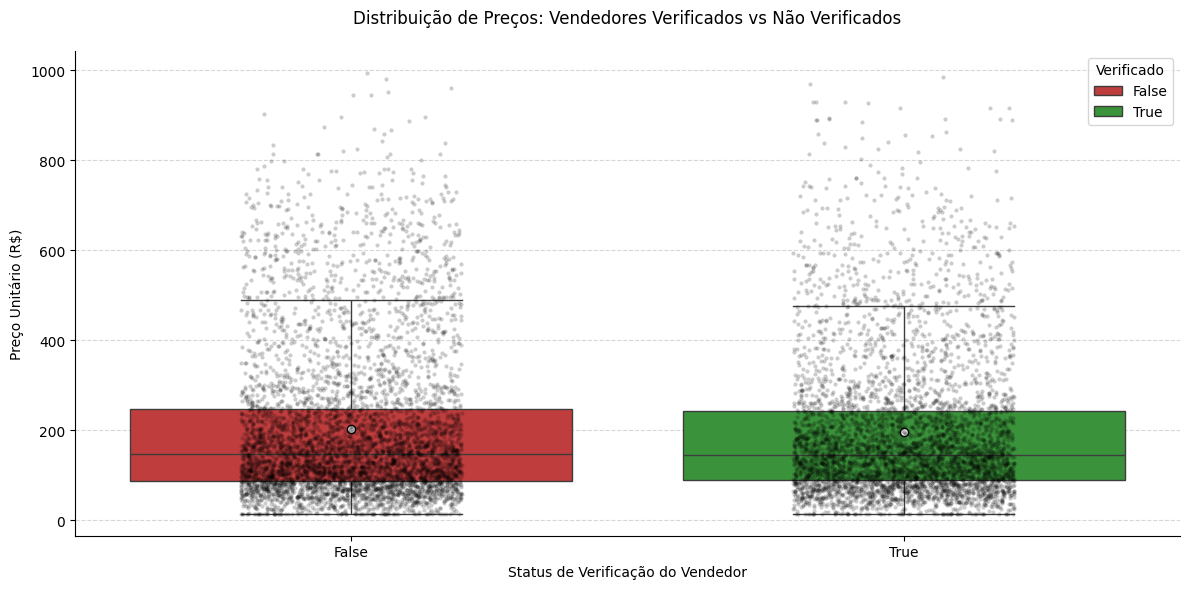

In [18]:
df_expandido = df_vendas_merged.loc[df_vendas_merged.index.repeat(df_vendas_merged['quantidade'])]

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_expandido,
    x='verificado',
    y='preco_unitario',
    color='black',
    size=3,
    alpha=0.2,
    jitter=0.2
)

plt.title('Distribuição de Preços: Vendedores Verificados vs Não Verificados', pad=20)
plt.xlabel('Status de Verificação do Vendedor')
plt.ylabel('Preço Unitário (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

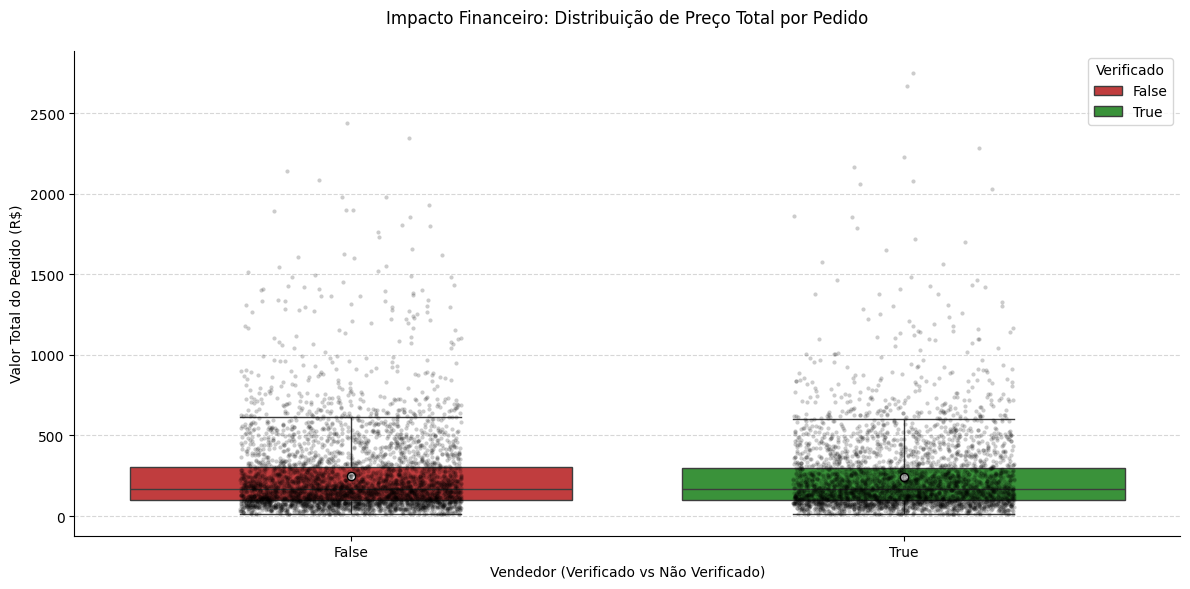

In [19]:
plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='valor_total',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged,
    x='verificado',
    y='valor_total',
    color='black',
    size=3,
    alpha=0.2,
    jitter=0.2
)

plt.title('Impacto Financeiro: Distribuição de Preço Total por Pedido', pad=20)
plt.xlabel('Vendedor (Verificado vs Não Verificado)')
plt.ylabel('Valor Total do Pedido (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

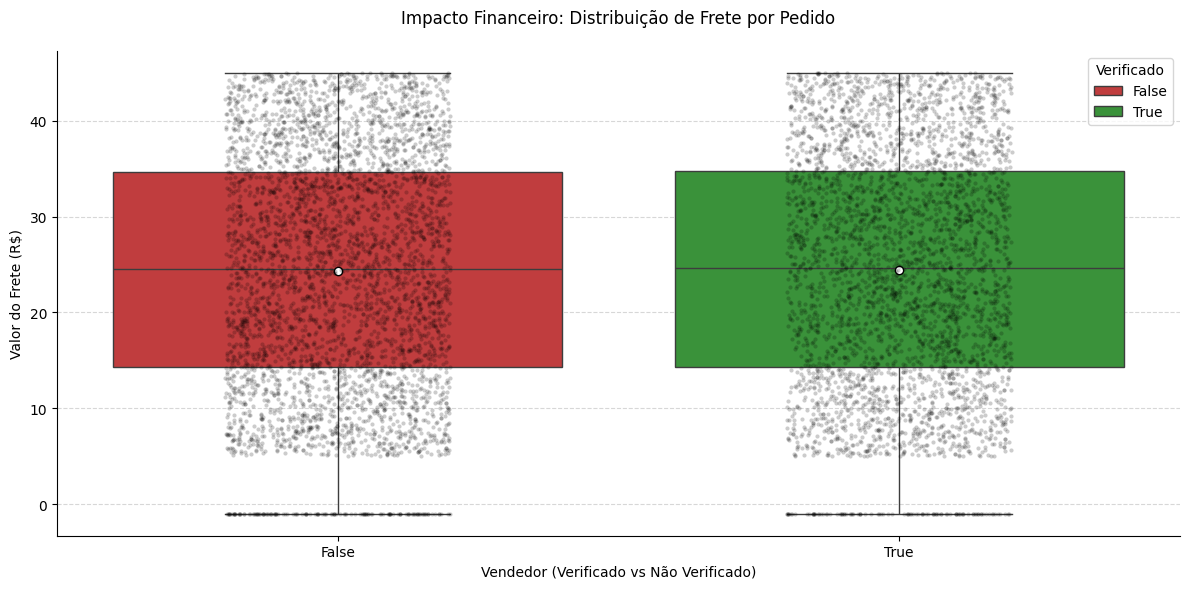

In [20]:
plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_vendas_merged,
    x='verificado',
    y='frete',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    dodge=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
    showfliers=False
)

sns.stripplot(
    data=df_vendas_merged,
    x='verificado',
    y='frete',
    color='black',
    size=3,
    alpha=0.2,
    jitter=0.2
)

plt.title('Impacto Financeiro: Distribuição de Frete por Pedido', pad=20)
plt.xlabel('Vendedor (Verificado vs Não Verificado)')
plt.ylabel('Valor do Frete (R$)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Verificado', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()


Valores Limpos

In [21]:
df_vendas_merged_clean_frete, outliers_frete = outlier_iqr(df_vendas_merged, 'frete')
df_vendas_merged_clean_vt, outliers_vendas = outlier_iqr(df_vendas_merged, 'valor_total')

df_expandido_clean_vt, outliers_expandido = outlier_iqr(df_expandido, 'preco_unitario')


Coluna: frete
Outliers removidos: 0
Limites: -16.23 a 65.24

Coluna: valor_total
Outliers removidos: 587
Limites: -207.35 a 608.93

Coluna: preco_unitario
Outliers removidos: 849
Limites: -149.40 a 483.82



In [22]:
estao_presentes = df_vendas_merged_clean_vt.index.isin(df_expandido_clean_vt.index).all()

if estao_presentes:
    print("Todos os Registros do DF Limpo estão no DF Expandido")
else:
    print("(!) Alguns registros do DF Limpo não estão presentes no DF Expandido")

(!) Alguns registros do DF Limpo não estão presentes no DF Expandido


In [25]:
ids_limpos = set(df_vendas_merged_clean_vt['pedido_id'])
ids_expandido = set(df_expandido_clean_vt['pedido_id'])

pedidos_restantes = ids_limpos - ids_expandido

if len(pedidos_restantes) == 0:
    print("Todos os Pedidos Id estão presentes")
else:
    print(f"(!) Faltam {len(pedidos_restantes)} ids para completar o DF Expandido")


(!) Faltam 308 ids para completar o DF Expandido


In [27]:
indices_removidos = set(outliers_vendas.index).union(set(outliers_expandido.index))

df_vendas_merged_final = df_vendas_merged.drop(index=indices_removidos, errors='ignore')
df_expandido_final = df_expandido.drop(index=indices_removidos, errors='ignore')

indices_validos = set(df_vendas_merged_clean_vt.index) & set(df_vendas_merged_clean_frete.index) & set(df_expandido_clean_vt.index)

indices_validos_removidos = df_vendas.index.difference(indices_validos)

df_vendas_final = df_vendas.drop(index=indices_validos_removidos)

print(f"Registros originais: {len(df_vendas)}")
print(f"Registros após remoção de outliers: {len(df_vendas_final)}")
print(f"Quantidade de Linhas Removidas: {len(indices_validos_removidos)}")

Registros originais: 8000
Registros após remoção de outliers: 7105
Quantidade de Linhas Removidas: 895


# 1. **Existem vendedores com padrão de vendas concentrado em horários atípicos** (madrugada, 2h-5h)? Quem são e qual o volume?

## Quantidade de Vendedores (Verificado x Não Verificado) por Hora do Pedido

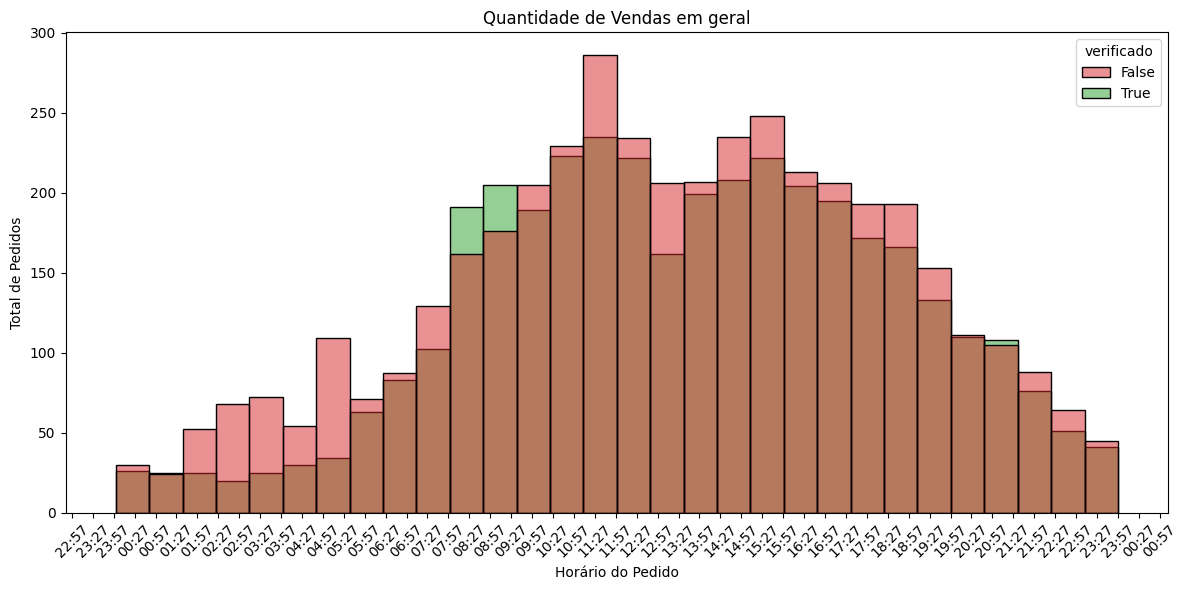

In [28]:
vendas_status_geral = df_vendas.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_geral,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas em geral", fontsize=12)
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

Vendedores com horáios atipicos (2h-5h)

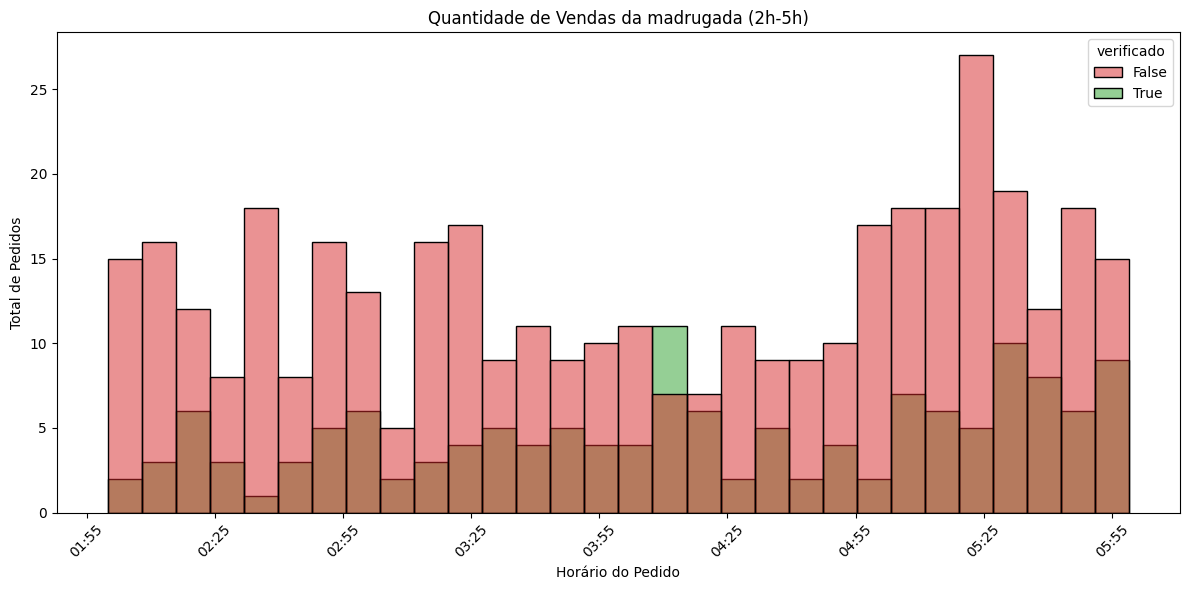

In [29]:

df_vendas_2_5 = df_vendas.query('_hora_pedido.dt.hour >= 2 and _hora_pedido.dt.hour <= 5')

vendas_status_2_5 = df_vendas_2_5.merge(df_vendedores[['vendedor_id', 'verificado']], on='vendedor_id', how='left')

plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=vendas_status_2_5,
    x='_hora_pedido',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    bins=30,
    multiple='layer'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

plt.xticks(rotation=45)
plt.title("Quantidade de Vendas da madrugada (2h-5h)")
plt.xlabel('Horário do Pedido')
plt.ylabel('Total de Pedidos')

plt.tight_layout()
plt.show()

Conclusões:
* Em comparação com o horário das 8 às 12 é quase irrelevante, melhor aguardar para ver novas informações
* Mesmo que seja visivel que as vendas dos não verificados é maior, é melhor considerar como um ponto futuro de análise

# 2. **Há avaliações falsas?** Identifique padrões: contas criadas há poucos dias que avaliam com nota 5, IPs repetidos, textos idênticos.

Tempo de Criação de Conta

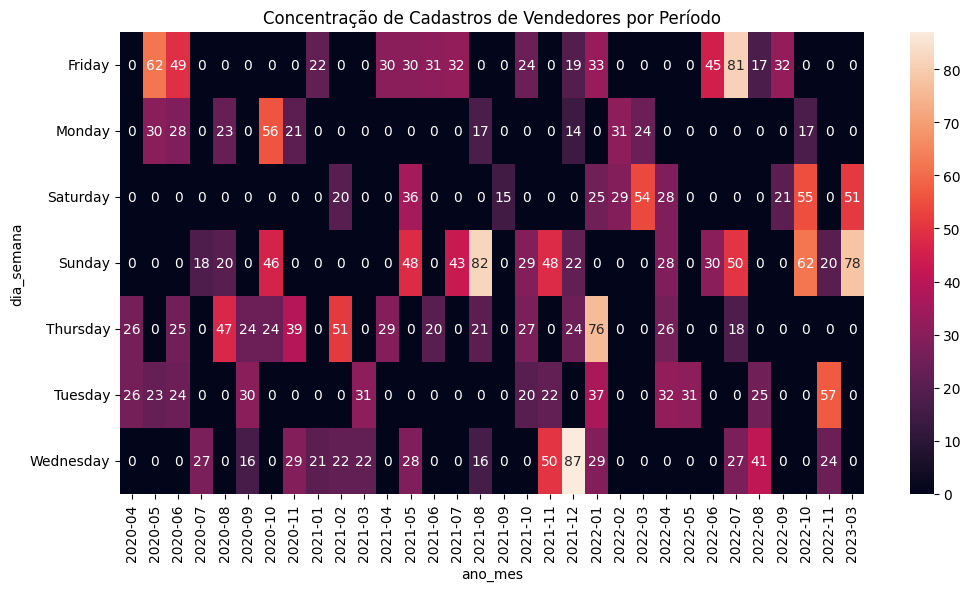

In [30]:
df_avl_suspeitas['tempo_criacao_conta_dias'] = (df_avl_suspeitas['data_avaliacao_dt'] - df_avl_suspeitas['data_criacao_conta_dt']
).dt.days


df_avl_suspeitas_info = df_avl_suspeitas.merge(df_vendedores, 
                                               on='vendedor_id', how='left')

df_avl_suspeitas_info['ano_mes'] = df_avl_suspeitas_info['_data_cadastro_dt'].dt.to_period('M')
df_avl_suspeitas_info['dia_semana'] = df_avl_suspeitas_info['_data_cadastro_dt'].dt.day_name()


pivot_cluster = df_avl_suspeitas_info.pivot_table(
    index='dia_semana', 
    columns='ano_mes', 
    values='vendedor_id', 
    aggfunc='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_cluster, annot=True)
plt.title('Concentração de Cadastros de Vendedores por Período')
plt.show()
picos_mes = df_avl_suspeitas_info.groupby('ano_mes').size()
meses_suspeitos = picos_mes[picos_mes > 50].index

In [33]:
df_avl_suspeitas_info['is_cluster_cadastro'] = df_avl_suspeitas_info['ano_mes'].isin(meses_suspeitos)
df_avl_suspeitas_info[df_avl_suspeitas_info['is_cluster_cadastro']]

,avaliacao_id,vendedor_id,comprador_id,data_avaliacao,data_criacao_conta,nota,ip_origem,texto_avaliacao,data_avaliacao_dt,data_criacao_conta_dt,...,estado,categoria_principal,total_vendas,nota_media_loja,reclamacoes,verificado,_data_cadastro_dt,ano_mes,dia_semana,is_cluster_cadastro
0,AVAL-00001,VEND-0019,COMP-02695,2023-11-01,2022-10-19,5,178.78.250.151,"Produto ok, dentro do esperado.",2023-11-01,2022-10-19,...,PE,Casa & Decoração,1575,2.9,23,True,2022-03-05,2022-03,Saturday,True
1,AVAL-00002,VEND-0118,COMP-00156,2023-10-20,2023-01-16,3,63.102.198.239,"Produto ok, dentro do esperado.",2023-10-20,2023-01-16,...,MA,Acessórios,1107,4.3,26,True,2021-12-30,2021-12,Thursday,True
2,AVAL-00003,VEND-0107,COMP-01834,2024-11-18,2024-05-13,5,147.114.196.226,Bom produto pelo preço.,2024-11-18,2024-05-13,...,MG,Eletrônicos,278,3.8,10,True,2020-11-25,2020-11,Wednesday,True
3,AVAL-00004,VEND-0079,COMP-04229,2023-03-25,2022-04-03,5,92.235.229.225,"Produto ok, dentro do esperado.",2023-03-25,2022-04-03,...,MG,Esporte & Lazer,1765,4.3,18,False,2020-09-10,2020-09,Thursday,True
4,AVAL-00005,VEND-0117,COMP-02844,2023-08-28,2022-07-12,1,187.99.250.54,Não gostei da qualidade.,2023-08-28,2022-07-12,...,RJ,Infantil,204,4.5,16,True,2020-05-25,2020-05,Monday,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AVAL-02996,VEND-0097,COMP-03864,2023-12-26,2023-09-25,4,26.178.153.226,Sem Comentário Explícito,2023-12-26,2023-09-25,...,PI,Infantil,680,4.1,18,False,2022-01-04,2022-01,Tuesday,True
2996,AVAL-02997,VEND-0043,COMP-01936,2023-07-29,2023-07-28,5,192.168.1.100,"Produto incrível, vendedor nota 10!",2023-07-29,2023-07-28,...,CE,Casa & Decoração,1104,4.8,2,False,2023-03-11,2023-03,Saturday,True
2997,AVAL-02998,VEND-0013,COMP-04226,2024-12-17,2024-10-23,5,182.36.180.222,Excelente custo-benefício.,2024-12-17,2024-10-23,...,PR,Moda Masculina,793,2.7,17,False,2021-05-30,2021-05,Sunday,True
2998,AVAL-02999,VEND-0050,COMP-02865,2023-01-09,2022-08-26,5,253.5.24.139,Demorou um pouco mas chegou bem.,2023-01-09,2022-08-26,...,GO,Acessórios,1156,4.4,2,True,2022-03-07,2022-03,Monday,True


In [34]:
df_avl_suspeitas_info['tempo_criacao_conta_dias'].describe()

count    3000.000000
mean      366.727000
std       208.722885
min         1.000000
25%       188.000000
50%       365.000000
75%       548.000000
max       730.000000
Name: tempo_criacao_conta_dias, dtype: float64

In [35]:
df_nota5 = df_avl_suspeitas_info.query("nota == 5")
df_nota5['verificado'].value_counts()

verificado
False    635
True     555
Name: count, dtype: int64

In [37]:
df_nota5[df_nota5['verificado'] == False]['tempo_criacao_conta_dias'].describe()

count    635.000000
mean     329.240945
std      229.784051
min        1.000000
25%      122.000000
50%      317.000000
75%      527.500000
max      730.000000
Name: tempo_criacao_conta_dias, dtype: float64

In [38]:
df_nota5[df_nota5['verificado'] == True]['tempo_criacao_conta_dias'].describe()

count    555.000000
mean     383.196396
std      201.503749
min       31.000000
25%      205.500000
50%      375.000000
75%      554.000000
max      729.000000
Name: tempo_criacao_conta_dias, dtype: float64

Distribuição do Tempo de Criação da Conta

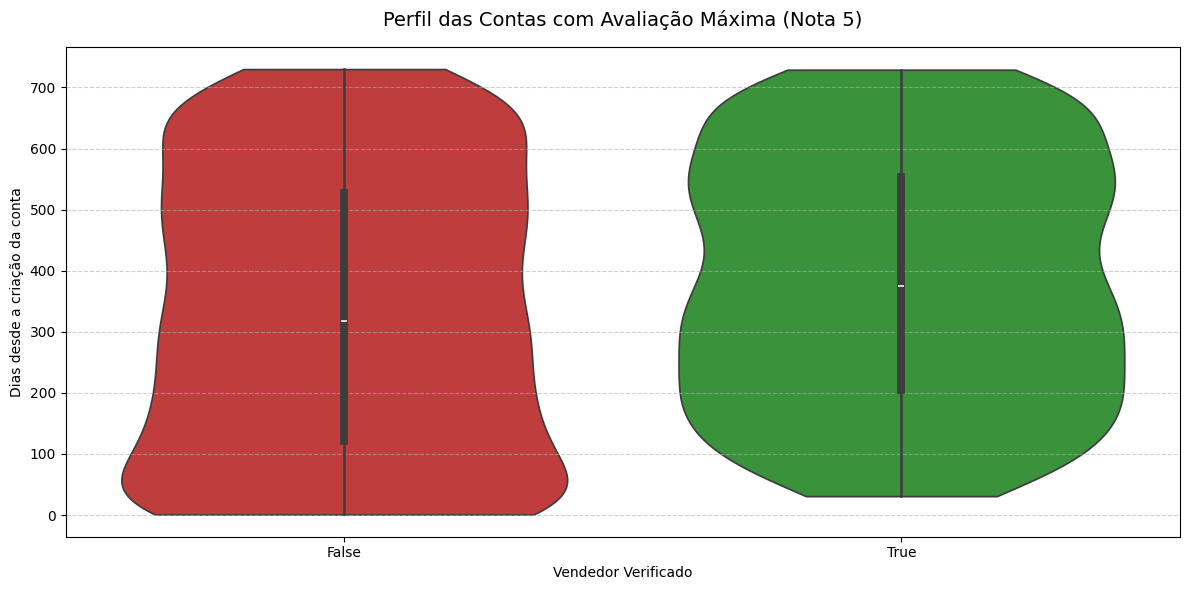

In [39]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='tempo_criacao_conta_dias', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.ylabel('Dias desde a criação da conta')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

<Axes: xlabel='verificado', ylabel='tempo_criacao_conta_dias'>

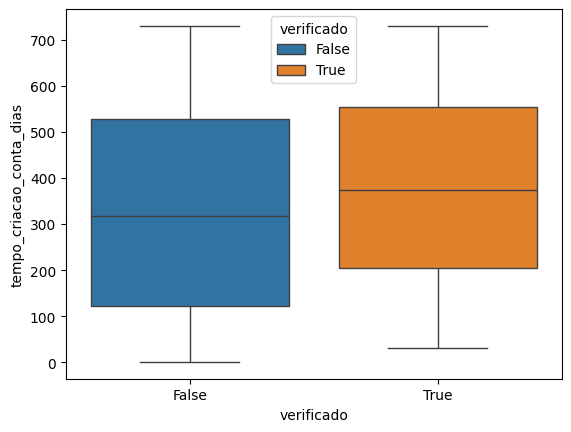

In [40]:
sns.boxplot(data=df_nota5, 
            y='tempo_criacao_conta_dias', 
            x='verificado',
            hue='verificado')

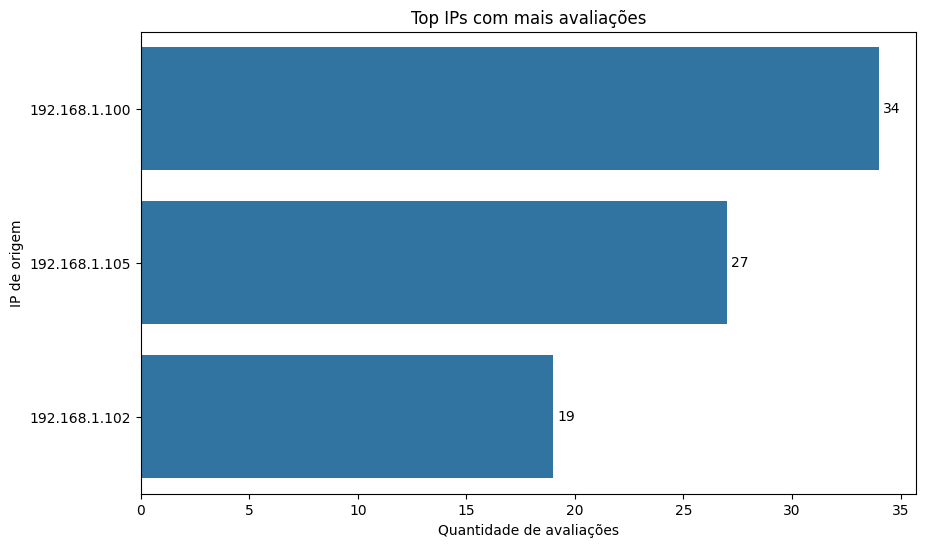

In [41]:
df_ips = df_nota5.groupby(
    ['vendedor_id', 'verificado', 'ip_origem']
).size().reset_index(name='contagem_por_ip').sort_values('contagem_por_ip', ascending=False)


top_ips = df_ips.groupby('ip_origem')['contagem_por_ip'] \
    .sum() \
    .sort_values(ascending=False) \
    .reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_ips.query('contagem_por_ip > 1'),
    x='contagem_por_ip',
    y='ip_origem',
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Top IPs com mais avaliações')
plt.xlabel('Quantidade de avaliações')
plt.ylabel('IP de origem')

plt.show()

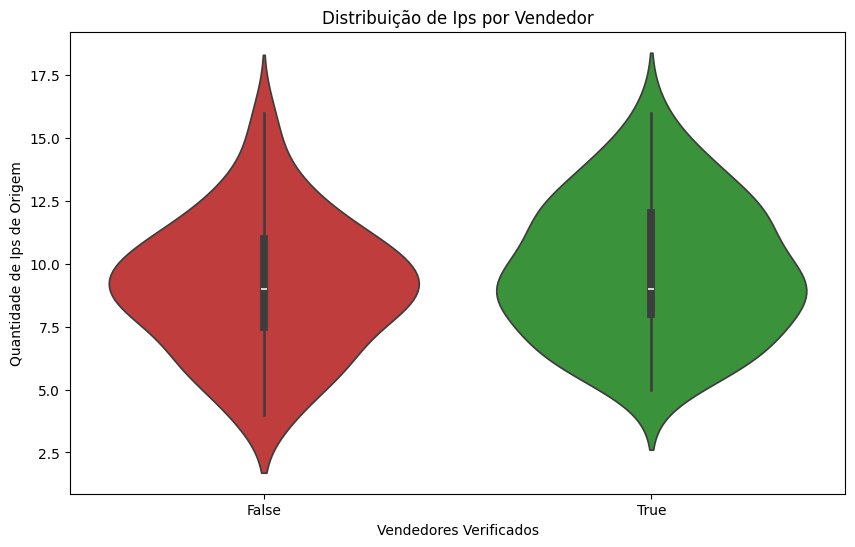

In [42]:
df_ips_vendedor = df_nota5.groupby(
    ['vendedor_id', 'verificado']
)['ip_origem'].nunique().reset_index(name='qtd_ips').sort_values('qtd_ips', ascending=False)


plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_ips_vendedor,
    x='verificado',
    y='qtd_ips',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'},
    legend=False
)

plt.title('Distribuição de Ips por Vendedor')
plt.xlabel('Vendedores Verificados')
plt.ylabel('Quantidade de Ips de Origem')

plt.show()

Distribuição de Ips por Vendedoor

In [43]:
vendedores_por_ip_nao_verificados = df_ips.query('verificado == False').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')


ips_verificados = vendedores_por_ip_nao_verificados.sort_values(by='qtd_vendedores', ascending=False)
ips_verificados.head(10)

,ip_origem,qtd_vendedores
219,192.168.1.105,5
217,192.168.1.100,5
218,192.168.1.102,5
2,1.202.158.15,1
3,1.34.57.240,1
4,1.67.235.15,1
5,10.141.219.124,1
6,10.165.227.175,1
7,10.240.116.22,1
8,10.26.252.128,1


In [44]:
vendedores_por_ip_verificados = df_ips.query('verificado == True').groupby('ip_origem')['vendedor_id'] \
    .nunique() \
    .reset_index(name='qtd_vendedores')


ips_verificados = vendedores_por_ip_verificados.sort_values(by='qtd_vendedores', ascending=False)
ips_verificados.head(10)

,ip_origem,qtd_vendedores
0,1.133.190.132,1
1,10.148.84.36,1
2,10.34.7.82,1
3,10.74.175.77,1
4,100.184.55.222,1
5,100.37.19.212,1
6,100.38.151.247,1
7,100.97.2.87,1
8,101.208.212.251,1
9,102.167.38.4,1


In [45]:
vendedores_por_ip_verificados.merge(
    vendedores_por_ip_nao_verificados,
    on='ip_origem',
    suffixes=('_nao_verificado', '_verificado')
)


,ip_origem,qtd_vendedores_nao_verificado,qtd_vendedores_verificado


Analise da Quantidade de Reclamações

In [46]:
df_nota5['reclamacoes'].value_counts().reset_index(name='quantidade').sort_values(by='quantidade',ascending=False)

,reclamacoes,quantidade
0,0,114
1,23,85
2,2,62
3,25,59
4,13,59
5,5,55
6,4,54
7,10,51
8,27,50
9,26,48


Análise de IP

In [47]:
df_ip_origem = df_nota5.groupby(
    ['ip_origem','vendedor_id', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_ip').sort_values(by='contagem_por_ip', ascending=False)

df_ip_origem.head(30)

,ip_origem,vendedor_id,verificado,contagem_por_ip
441,192.168.1.100,VEND-0043,False,9
443,192.168.1.100,VEND-0045,False,8
453,192.168.1.105,VEND-0045,False,7
454,192.168.1.105,VEND-0046,False,7
444,192.168.1.100,VEND-0046,False,7
442,192.168.1.100,VEND-0044,False,6
450,192.168.1.105,VEND-0042,False,5
451,192.168.1.105,VEND-0043,False,5
446,192.168.1.102,VEND-0043,False,5
447,192.168.1.102,VEND-0044,False,5


Top IPS

Text(0, 0.5, 'IP de origem')

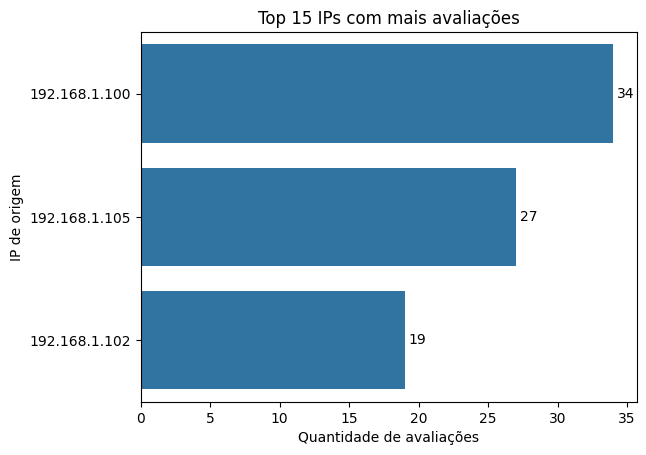

In [48]:
top_ips = df_ip_origem.groupby("ip_origem")['contagem_por_ip'].sum().sort_values(ascending=False).reset_index()

ax = sns.barplot(
    data=top_ips.query('contagem_por_ip > 1').head(15),
    x='contagem_por_ip',
    y='ip_origem',
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Top 15 IPs com mais avaliações')
plt.xlabel('Quantidade de avaliações')
plt.ylabel('IP de origem')

Análise de Rede/Subrede/SubRede Local

In [49]:
df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
df_nota5['subrede_local'] = df_nota5['ip_origem'].str.split(".").str[0:3].str.join(".")


C:\Users\rpf97\AppData\Local\Temp\ipykernel_21372\1169564160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['rede'] = df_nota5['ip_origem'].str.split(".").str[0:1].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_21372\1169564160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nota5['subrede'] = df_nota5['ip_origem'].str.split(".").str[0:2].str.join(".")
C:\Users\rpf97\AppData\Local\Temp\ipykernel_21372\1169564160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a 

In [50]:
df_nota5.groupby(
    ['rede','vendedor_id', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_ip_rede').sort_values(by='contagem_por_ip_rede', ascending=False)


,rede,vendedor_id,verificado,contagem_por_ip_rede
435,192,VEND-0043,False,19
437,192,VEND-0045,False,19
438,192,VEND-0046,False,17
436,192,VEND-0044,False,14
434,192,VEND-0042,False,11
...,...,...,...,...
1077,95,VEND-0049,True,1
1078,95,VEND-0062,True,1
1079,96,VEND-0003,True,1
1080,96,VEND-0005,False,1


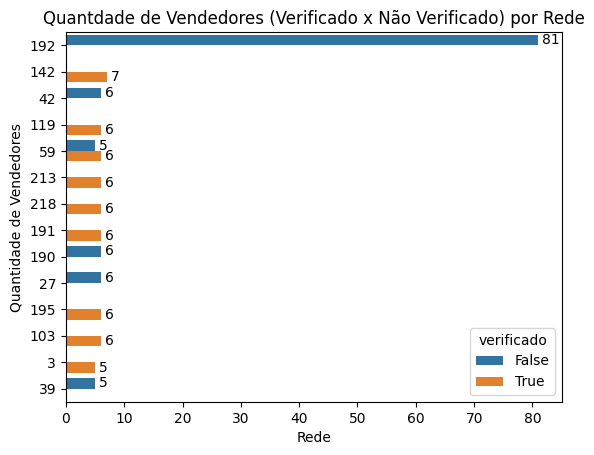

In [51]:
df_ip_rede = df_nota5.groupby(
    ['rede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_ip_rede').sort_values(by='contagem_ip_rede', ascending=False)

ax = sns.barplot(
    data=df_ip_rede.head(15),
    y='rede',
    x='contagem_ip_rede', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por Rede")
plt.xlabel("Rede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

Ponto de Atenção: Simplificar o IP como rede não funcionaria pois apresenta um conjunto mais amplo

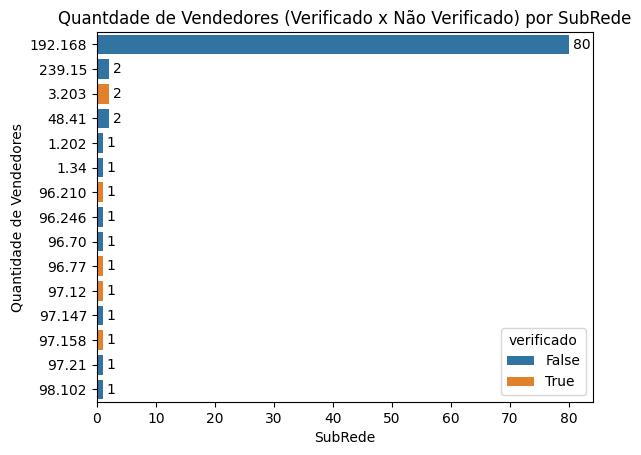

In [52]:
df_ip_subrede = df_nota5.groupby(
    ['subrede', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_subrede').sort_values(by='contagem_por_subrede', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede.head(15),
    y='subrede',
    x='contagem_por_subrede', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede")
plt.xlabel("SubRede")
plt.ylabel("Quantidade de Vendedores")
plt.show()

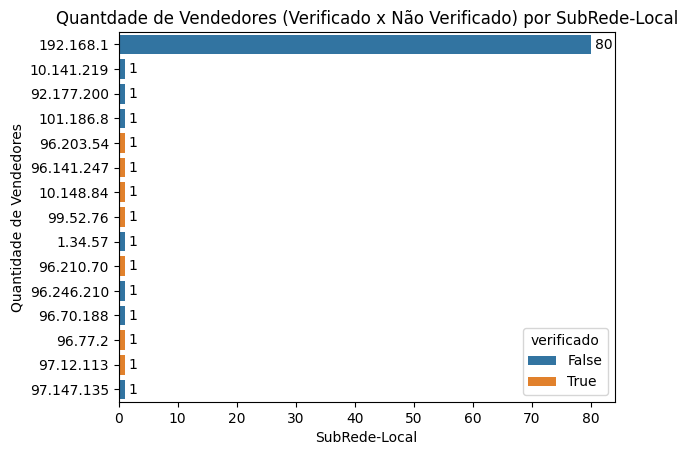

In [53]:
df_ip_subrede_local = df_nota5.groupby(
    ['subrede_local', 'verificado']
)['vendedor_id'].size().reset_index(name='contagem_por_subrede_local').sort_values(by='contagem_por_subrede_local', ascending=False)

ax = sns.barplot(
    data=df_ip_subrede_local.head(15),
    y='subrede_local',
    x='contagem_por_subrede_local', 
    hue='verificado'
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title("Quantdade de Vendedores (Verificado x Não Verificado) por SubRede-Local")
plt.xlabel("SubRede-Local")
plt.ylabel("Quantidade de Vendedores")
plt.show()

Quantidade de textos mais comuns por vendedor

In [54]:
df_textos = df_nota5.groupby(
    ['texto_avaliacao', 'verificado'], dropna=False
).size().reset_index(name='contagem')

top_textos = df_textos.sort_values('contagem', ascending=False).head(15)
top_textos

,texto_avaliacao,verificado,contagem
5,Excelente custo-benefício.,False,78
17,"Recomendo, boa experiência.",True,75
10,Não gostei da qualidade.,True,74
21,"Veio com defeito, pedi troca.",False,65
14,"Produto ok, dentro do esperado.",False,63
1,Bom produto pelo preço.,True,61
12,Produto diferente da foto.,True,61
9,Não gostei da qualidade.,False,61
15,"Produto ok, dentro do esperado.",True,61
16,"Recomendo, boa experiência.",False,60


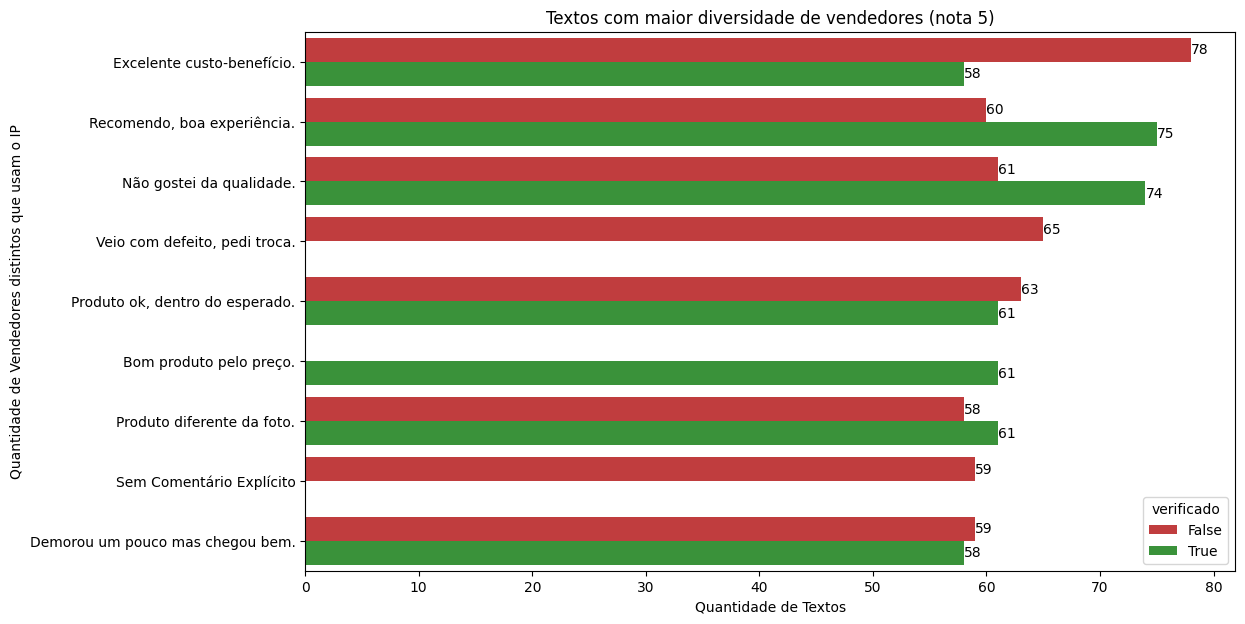

In [55]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_textos,
    x='contagem',
    y='texto_avaliacao',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}
)

for x in ax.containers:
    ax.bar_label(x)

plt.title('Textos com maior diversidade de vendedores (nota 5)')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Quantidade de Vendedores distintos que usam o IP')
plt.show()

Quantidade de Categorias por Vendedor (Verificado x Não Verificado)

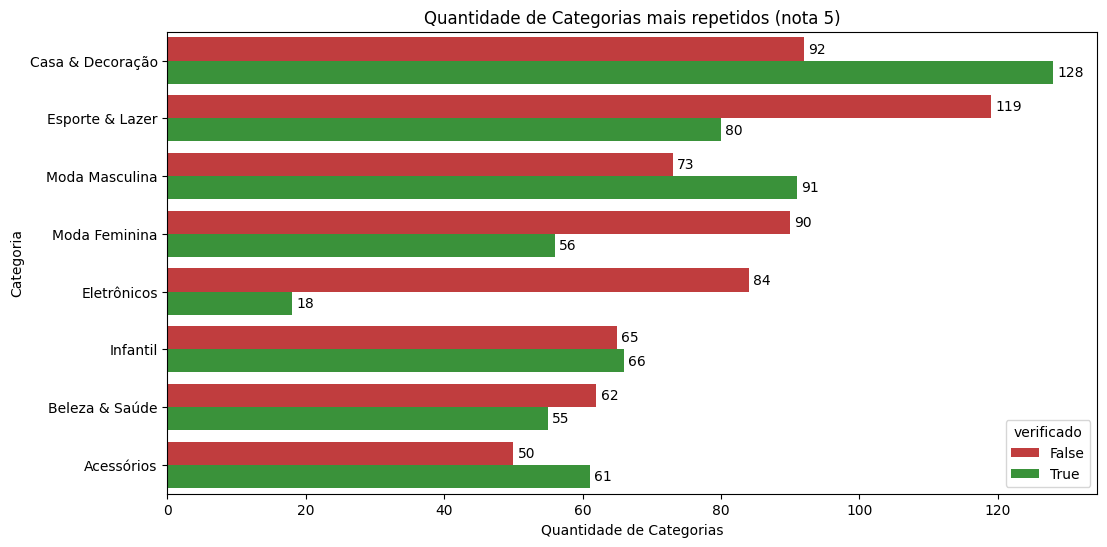

In [56]:
def_quant_categorias = df_nota5.groupby(
    ['categoria_principal', 'verificado']
).size().reset_index(name='contagem_categorial_principal').sort_values(by='contagem_categorial_principal', ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    def_quant_categorias,
    x='contagem_categorial_principal',
    y='categoria_principal',
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'} 
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.title('Quantidade de Categorias mais repetidos (nota 5)')
plt.xlabel("Quantidade de Categorias")
plt.ylabel("Categoria")
plt.show()

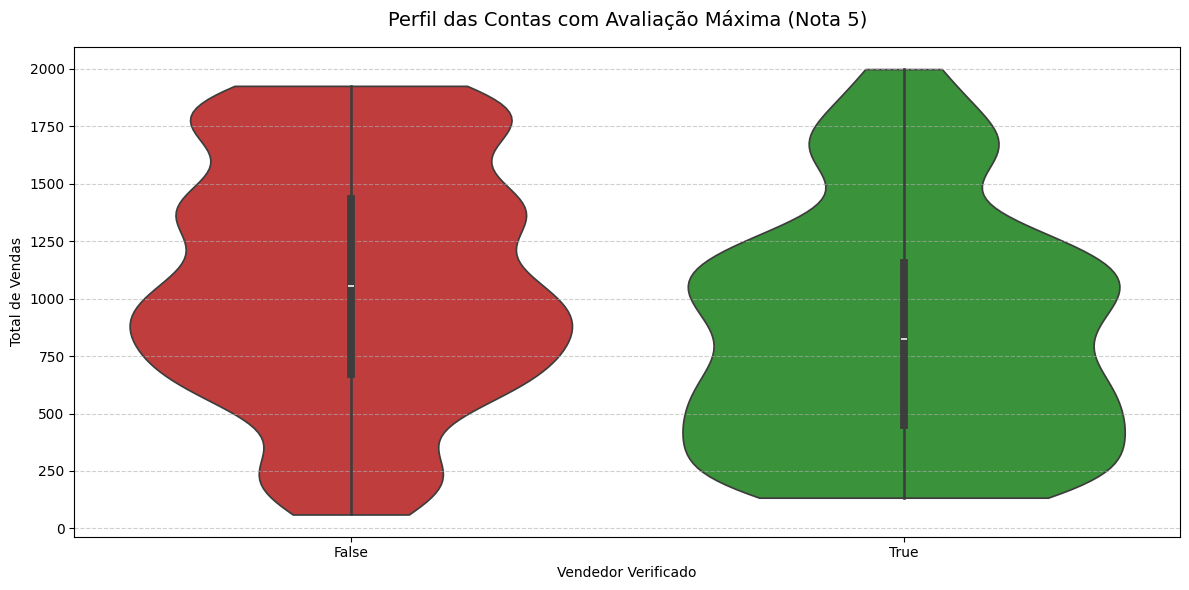

In [57]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='total_vendas', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

# Estilização extra
plt.grid(axis='y', linestyle='--', alpha=0.6) # Ajuda a ler os dias exatos
plt.ylabel('Total de Vendas')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

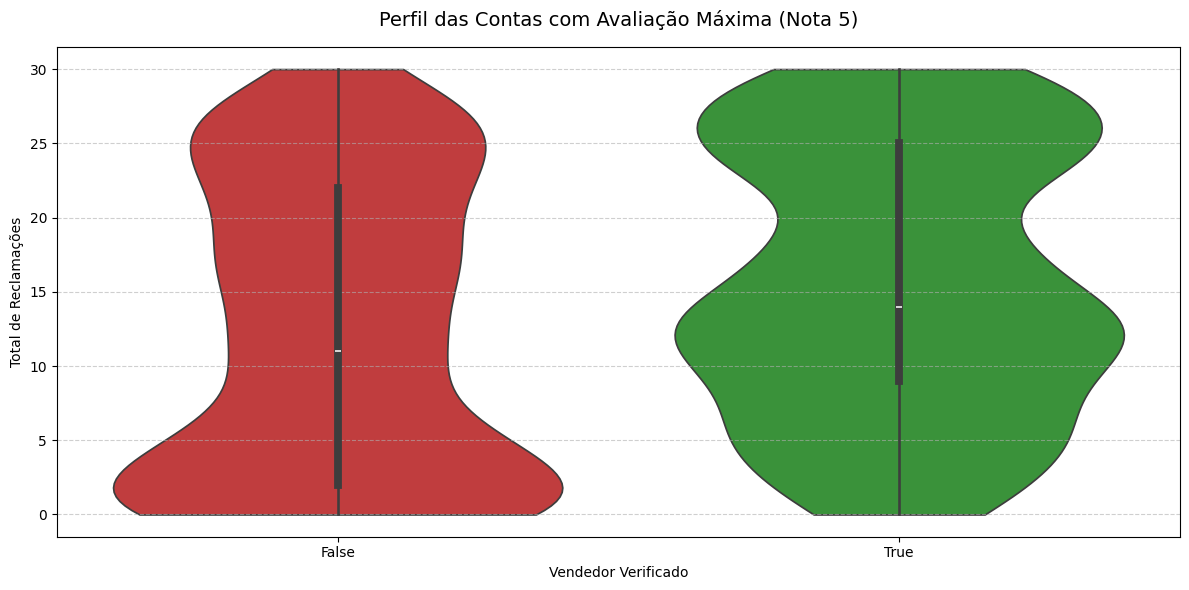

In [58]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_nota5, 
    x='verificado',
    y='reclamacoes', 
    hue='verificado',
    palette={True: '#2ca02c', False: '#d62728'}, 
    inner="box",
    cut=0,
    legend=False
)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel('Total de Reclamações')
plt.xlabel('Vendedor Verificado')
plt.title('Perfil das Contas com Avaliação Máxima (Nota 5)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

df_avl_suspeitas_info['subrede'] = df_avl_suspeitas_info['ip_origem'].str.split(".").str[0:2].str.join(".")

df_avl_suspeitas_info['possui_ips_repetidos'] = (
    df_avl_suspeitas_info.groupby(['subrede', 'verificado'])['vendedor_id'].transform("size") > 1
)

df_avl_suspeitas_info['possui_textos_repetidos'] = (
    df_avl_suspeitas_info.groupby(['texto_avaliacao', 'verificado'])['vendedor_id'].transform("size") > 1
)

df_avl_suspeitas_info['possui_reclamacoes'] = (df_avl_suspeitas_info['reclamacoes'] > 0)


df_avl_suspeitas_info['score'] = (
    ((df_avl_suspeitas_info['possui_ips_repetidos'] & (df_avl_suspeitas_info['nota'] == 5)).astype("int") * 5)
    
    + (df_avl_suspeitas_info['possui_textos_repetidos'] & (df_avl_suspeitas_info['nota'] == 5)).astype("int")
    
    + ((df_avl_suspeitas_info['possui_reclamacoes']) & (df_avl_suspeitas_info['nota'] == 5)).astype("int")
    
    + (((df_avl_suspeitas_info['tempo_criacao_conta'] < 30) 
       & (df_avl_suspeitas_info['nota'] == 5)).astype("int") * 5)
).astype("int")

## 3. **Os vendedores suspeitos compartilham características em comum?** Cruze com o cadastro: data de cadastro próxima, mesma cidade, nomes similares, não verificados.

## 6. **Construa um "score de risco"** baseado nos indicadores encontrados. Quais critérios compõem esse score?

In [61]:
df_nota5['ip_origem'].value_counts().reset_index(name='qtd_ips').sort_values(by='qtd_ips', ascending=False)

,ip_origem,qtd_ips
0,192.168.1.100,34
1,192.168.1.105,27
2,192.168.1.102,19
3,162.192.61.55,1
4,169.146.134.113,1
...,...,...
1108,159.83.191.210,1
1109,165.101.56.70,1
1110,21.53.217.171,1
1111,117.183.167.62,1


In [60]:
df_nota5['rede'].value_counts().reset_index(name='qtd_ips').sort_values(by='qtd_ips', ascending=False)

,rede,qtd_ips
0,192,84
1,59,11
2,42,10
3,213,9
4,194,9
...,...,...
245,186,1
246,50,1
247,110,1
248,8,1


In [62]:
df_nota5['subrede'].value_counts().reset_index(name='qtd_ips').sort_values(by='qtd_ips', ascending=False)

,subrede,qtd_ips
0,192.168,80
1,33.5,2
2,3.203,2
3,239.15,2
4,3.224,2
...,...,...
1096,100.97,1
1097,159.83,1
1098,165.101,1
1099,21.53,1


In [63]:
df_nota5['subrede_local'].value_counts().reset_index(name='qtd_ips').sort_values(by='qtd_ips', ascending=False)

,subrede_local,qtd_ips
0,192.168.1,80
1,42.182.234,1
2,210.55.90,1
3,81.18.77,1
4,162.192.61,1
...,...,...
1106,159.83.191,1
1107,165.101.56,1
1108,21.53.217,1
1109,117.183.167,1


In [119]:
(df_avl_suspeitas_info['verificado'] == False).astype("int")

0       0
1       0
2       0
3       1
4       0
       ..
2995    1
2996    1
2997    1
2998    0
2999    1
Name: verificado, Length: 3000, dtype: int64

In [130]:
df_nota5['subrede'].value_counts().head(15)

subrede
192.168    80
33.5        2
3.203       2
239.15      2
3.224       2
242.57      2
194.233     2
146.216     2
52.245      2
18.39       2
48.41       2
92.235      1
169.126     1
18.202      1
96.203      1
Name: count, dtype: int64

In [131]:

# Configuração de Pesos (Ajuste aqui)
PESOS_RISCO = {
    'nao_verificado': 1,
    'nota_alta_recente': 3,
    'ip_multi_nota_alta': 4,
    'conflito_reclamacao': 2
}

# 1. Flag Não Verificado
df_avl_suspeitas_info['flag_nao_verificado'] = (df_avl_suspeitas_info['verificado'] == False).astype("int")


# 2. Nota Alta mais Recente
df_avl_suspeitas_info['flag_nota_alta_recente'] = (
    (df_avl_suspeitas_info['nota'] == 5) 
    & (df_avl_suspeitas_info['tempo_criacao_conta_dias'] <= 30)
).astype("int")


# 3. Análise de IP (Refinada para focar em IPs com múltiplas avaliações nota 5)
ips_suspeitos = df_nota5['ip_origem'].value_counts()
ips_suspeitos = ips_suspeitos[ips_suspeitos > 1].index

df_avl_suspeitas_info['flag_ip_multi_nota_alta'] = (
    df_avl_suspeitas_info['ip_origem'].isin(ips_suspeitos) 
    & (df_avl_suspeitas_info['nota'] == 5)
).astype("int")


# 4. Conflito de Sentimento
df_avl_suspeitas_info['flag_conflito_reclamacao_nota'] = (
    (df_avl_suspeitas_info['reclamacoes'] > 10) & (df_avl_suspeitas_info['nota'] == 5)
).astype("int")

# 5. Cálculo do Score de Risco
df_avl_suspeitas_info['score_risco'] = (
    (df_avl_suspeitas_info['flag_nao_verificado'] * PESOS_RISCO['nao_verificado']) +
    (df_avl_suspeitas_info['flag_nota_alta_recente'] * PESOS_RISCO['nota_alta_recente']) +
    (df_avl_suspeitas_info['flag_ip_multi_nota_alta'] * PESOS_RISCO['ip_multi_nota_alta']) +
    (df_avl_suspeitas_info['flag_conflito_reclamacao_nota'] * PESOS_RISCO['conflito_reclamacao'])
)

In [132]:
ranking_vendedores = df_avl_suspeitas_info.groupby(['vendedor_id']).agg({
    'score_risco': "mean",
    "avaliacao_id": "count"
}).rename(columns={'avaliacao_id': 'qtd_avaliacoes_analisadas'}).round(2).reset_index()

vendedores_suspeitos = ranking_vendedores[ranking_vendedores['score_risco'] >= 3].sort_values(by='score_risco', ascending=False)

print("Lista de Vendedores Suspeitos para Auditoria:")
print(vendedores_suspeitos)

Lista de Vendedores Suspeitos para Auditoria:
   vendedor_id  score_risco  qtd_avaliacoes_analisadas
45   VEND-0046         6.67                         21
44   VEND-0045         5.43                         30
42   VEND-0043         5.43                         30
41   VEND-0042         4.85                         20
43   VEND-0044         4.50                         28


<function matplotlib.pyplot.show(close=None, block=None)>

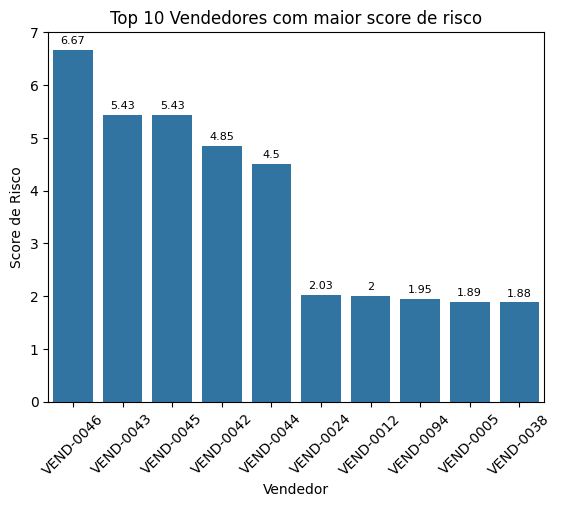

In [133]:
top_risco = ranking_vendedores.sort_values(by='score_risco', ascending=False).head(10)

ax = sns.barplot(
    data=top_risco,
    x='vendedor_id',
    y='score_risco'
)

for c in ax.containers:
    ax.bar_label(c, padding=3, fontsize=8)

plt.xlabel("Vendedor")
plt.ylabel("Score de Risco")
plt.title("Top 10 Vendedores com maior score de risco")
plt.xticks(rotation=45)
plt.show


In [ ]:
## 4. **Qual o impacto financeiro** das vendas dos vendedores suspeitos? Quanto representam do faturamento total?

In [138]:
suspeitos = vendedores_suspeitos['vendedor_id']

percentual_suspeitos = (
        (df_vendedores[df_vendedores['vendedor_id'].isin(suspeitos)]['total_vendas'].sum()) 
        / (df_vendedores['total_vendas'].sum())
    ) * 100


percentual_faturamento_suspeitos = (
        (df_vendas_final[df_vendas_final['vendedor_id'].isin(suspeitos)]['valor_total'].sum()) 
        / (df_vendas_final['valor_total'].sum())
    ) * 100

print(f'{(df_vendedores[df_vendedores['vendedor_id'].isin(suspeitos)]['total_vendas'].sum()):.2f} vendas de vendedores suspeitos {percentual_suspeitos:.2f} % do total\n')

print(f'Faturamento de {
    (df_vendas_final[df_vendas_final['vendedor_id'].isin(suspeitos)]['valor_total'].sum()):.2f} R$ representando {percentual_faturamento_suspeitos:.2f} % do faturamento total')



5829.00 vendas de vendedores suspeitos 5.09 % do total

Faturamento de 51816.25 R$ representando 4.04 % do faturamento total


## 5. **A taxa de cancelamento/devolução** dos vendedores suspeitos é diferente dos demais?

In [104]:
total_vendas = df_vendas_final['status_pedido'].value_counts()

df_status_suspeitos = df_vendas_final['status_pedido'][df_vendas_final['vendedor_id'].isin(suspeitos)].value_counts()

df_taxa_cancelamento = pd.DataFrame({'total_geral': total_vendas, 'vendas_suspeitas': df_status_suspeitos})

df_taxa_cancelamento['taxa_geral_%'] = ((
    df_taxa_cancelamento['total_geral']/df_taxa_cancelamento['total_geral'].sum()
)*100).round(2)

df_taxa_cancelamento['taxa_vendas_suspeitas_%'] = ((
    df_taxa_cancelamento['vendas_suspeitas']/df_taxa_cancelamento['vendas_suspeitas'].sum()
)*100).round(2)

df_taxa_cancelamento = df_taxa_cancelamento.reset_index().rename({"index": "status_pedido"})

In [105]:
df_taxa_cancelamento

,status_pedido,total_geral,vendas_suspeitas,taxa_geral_%,taxa_vendas_suspeitas_%
0,Cancelado,878,25,12.36,8.77
1,Devolvido,868,35,12.22,12.28
2,Em trânsito,901,33,12.68,11.58
3,Entregue,4458,192,62.74,67.37


Conclusões
* A maioria dos pedidos é entregue cerca de 62.74 % nas vendas em geral e 67.37 % nas vendas suspeitas
* A taxa de cancelamento entre vendedores suspeitos (8.77) é menor comparado com a taxa de cancelamento das vendas em geral (12.36)
* A taxa de devolução é semelhante tanto em vendas em geral (12.22) quanto em vendas suspeitas (12.28)

## 7. **Proponha regras automáticas** para detectar fraudes futuras baseadas nos padrões descobertos.


Regras

1 O Horário é Irrelevante até o Momento